<h1>Bases de Datos para el Big Data</h1>

<h2>03 - MongoDB: Agregación avanzada - Analytics y Machine Learning</h2>
<br>
<i>Autor: Marlon Cárdenas Bonett</i>
<br>
<i>Año: 2026</i>

### Análisis avanzado con agregación y predicción con ML

## Introducción

En este taller avanzado exploraremos técnicas sofisticadas de agregación en MongoDB que aprovechan al máximo el formato JSON y las capacidades analíticas de la base de datos. Cubriremos:

**Contenido del taller:**
1. **Agregaciones complejas con documentos embebidos**: Construcción de estructuras JSON enriquecidas con múltiples métricas
2. **Operadores de acumulación avanzados**: $push, $addToSet, $first, $last combinados con cálculos estadísticos
3. **Vistas materializadas**: Creación y mantenimiento de vistas pre-calculadas para análisis rápido
4. **$merge y $out**: Actualización incremental de colecciones agregadas
5. **Machine Learning**: Preparación de datos y predicción usando regresión logística

**Casos de uso:**
- Dashboard de métricas de negocio en tiempo real
- Segmentación de clientes con múltiples dimensiones
- Predicción de comportamiento de compra
- Detección de patrones y anomalías

## 1. Preparación del entorno

Configuramos la conexión a MongoDB y cargamos los datos necesarios.

In [1]:
# Importar bibliotecas necesarias
import pymongo
import json
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from bson import ObjectId
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Conectar a MongoDB
mongoClient = pymongo.MongoClient("mongodb://localhost:27017/?readPreference=primary")
db = mongoClient.airbnb

# Obtener colecciones
clientesColl = db.clientes
comprasColl = db.compras

print(f"Clientes en la base de datos: {clientesColl.count_documents({})}")
print(f"Compras en la base de datos: {comprasColl.count_documents({})}")

Clientes en la base de datos: 200
Compras en la base de datos: 2061


## 2. Agregaciones avanzadas con documentos embebidos

Vamos a crear agregaciones que generen documentos JSON complejos con múltiples niveles de anidación y métricas calculadas.

### 2.1 Perfil 360° del cliente

Creamos un documento embebido completo para cada cliente que incluye:
- Información demográfica
- Métricas de compra (totales, promedios, máximos, mínimos)
- Lista de productos favoritos
- Comportamiento temporal
- Score de valor del cliente (CLV)

In [3]:
pipeline_perfil_360 = [
    # 1. Lookup para unir con compras
    {
        "$lookup": {
            "from": "compras",
            "localField": "_id",
            "foreignField": "cliente_id",
            "as": "compras"
        }
    },
    # 2. Filtrar solo clientes con compras
    {
        "$match": {
            "compras": {"$ne": []}
        }
    },
    # 3. Unwind de compras para procesar artículos
    {"$unwind": "$compras"},
    {"$unwind": "$compras.articulos"},
    # 4. Agrupar y calcular métricas complejas
    {
        "$group": {
            "_id": "$_id",
            # Información básica del cliente
            "info_cliente": {
                "$first": {
                    "nombre": "$nombre",
                    "email": "$email",
                    "ciudad": "$direccion.ciudad",
                    "estatus": "$estatus",
                    "puntos_fidelidad": "$puntos_fidelidad",
                    "fecha_registro": "$fecha_registro"
                }
            },
            # Métricas financieras
            "metricas_financieras": {
                "$first": {
                    "valor_total_compras": {"$sum": "$compras.total"},
                    "ticket_promedio": {"$avg": "$compras.total"},
                    "compra_maxima": {"$max": "$compras.total"},
                    "compra_minima": {"$min": "$compras.total"},
                    "numero_compras": {"$sum": 1}
                }
            },
            # Acumular IDs de compras
            "ids_compras": {"$addToSet": "$compras._id"},
            # Productos comprados (sin duplicados)
            "productos_unicos": {"$addToSet": "$compras.articulos.nombre"},
            # Cantidad total de unidades compradas
            "unidades_totales": {"$sum": "$compras.articulos.cantidad"},
            # Categorías de productos
            "categorias_compradas": {"$addToSet": "$compras.articulos.nombre"},
            # Métodos de pago utilizados
            "metodos_pago": {"$addToSet": "$compras.metodo_pago"},
            # Estados de pedidos
            "estados_pedidos": {"$addToSet": "$compras.estatus"},
            # Fechas de compras
            "fechas_compras": {"$push": "$compras.fecha"},
            # Primera y última compra
            "primera_compra": {"$min": "$compras.fecha"},
            "ultima_compra": {"$max": "$compras.fecha"}
        }
    },
    # 5. Agregar campos calculados complejos
    {
        "$addFields": {
            "metricas_comportamiento": {
                "dias_cliente": {
                    "$divide": [
                        {"$subtract": ["$ultima_compra", "$primera_compra"]},
                        86400000  # milisegundos en un día
                    ]
                },
                "frecuencia_compra_dias": {
                    "$cond": {
                        "if": {"$gt": [{"$size": "$ids_compras"}, 1]},
                        "then": {
                            "$divide": [
                                {"$subtract": ["$ultima_compra", "$primera_compra"]},
                                {"$multiply": [{"$size": "$ids_compras"}, 86400000]}
                            ]
                        },
                        "else": 0
                    }
                },
                "diversidad_productos": {"$size": "$productos_unicos"},
                "diversidad_metodos_pago": {"$size": "$metodos_pago"}
            },
            # Calcular Customer Lifetime Value (CLV) simplificado
            "clv_score": {
                "$multiply": [
                    {"$size": "$ids_compras"},
                    10  # Factor de ponderación
                ]
            },
            # Segmentación automática
            "segmento": {
                "$switch": {
                    "branches": [
                        {
                            "case": {"$gte": [{"$size": "$ids_compras"}, 5]},
                            "then": "VIP"
                        },
                        {
                            "case": {"$gte": [{"$size": "$ids_compras"}, 3]},
                            "then": "Premium"
                        },
                        {
                            "case": {"$gte": [{"$size": "$ids_compras"}, 2]},
                            "then": "Regular"
                        }
                    ],
                    "default": "Nuevo"
                }
            }
        }
    },
    # 6. Proyección final
    {
        "$project": {
            "_id": 1,
            "info_cliente": 1,
            "metricas_financieras": 1,
            "metricas_comportamiento": 1,
            "productos_unicos": 1,
            "metodos_pago": 1,
            "clv_score": 1,
            "segmento": 1,
            "primera_compra": 1,
            "ultima_compra": 1
        }
    },
    {"$limit": 3}
]

perfiles_360 = list(clientesColl.aggregate(pipeline_perfil_360))
print("\n=== PERFIL 360° DE CLIENTES ===\n")
print(json.dumps(perfiles_360, indent=2, default=str))


=== PERFIL 360° DE CLIENTES ===

[
  {
    "_id": "CL98",
    "info_cliente": {
      "nombre": "Richard Barber",
      "email": "richard.barber@example.com",
      "ciudad": "Puebla",
      "estatus": "activo",
      "puntos_fidelidad": 405,
      "fecha_registro": "2021-11-10 20:53:59.824000"
    },
    "metricas_financieras": {
      "valor_total_compras": 100.5,
      "ticket_promedio": 100.5,
      "compra_maxima": 100.5,
      "compra_minima": 100.5,
      "numero_compras": 1
    },
    "productos_unicos": [
      "Smartphone",
      "Libro de cocina",
      "Laptop",
      "Zapatos deportivos",
      "C\u00e1mara",
      "Reloj inteligente",
      "Mochila"
    ],
    "metodos_pago": [
      "tarjeta_credito"
    ],
    "primera_compra": "2024-02-15 03:33:31.828000",
    "ultima_compra": "2024-05-07 11:17:43.829000",
    "metricas_comportamiento": {
      "dias_cliente": 82.32236112268518,
      "frecuencia_compra_dias": 6.33248931712963,
      "diversidad_productos": 7,
      

### 2.2 Análisis de cohortes con documentos embebidos

Creamos un análisis de cohortes basado en el mes de registro, con métricas agregadas por mes de actividad.

In [4]:
pipeline_cohortes = [
    {
        "$lookup": {
            "from": "compras",
            "localField": "_id",
            "foreignField": "cliente_id",
            "as": "compras"
        }
    },
    {
        "$addFields": {
            "fecha_registro_obj": {"$toDate": "$fecha_registro"},
            "mes_registro": {
                "$dateToString": {
                    "format": "%Y-%m",
                    "date": {"$toDate": "$fecha_registro"}
                }
            }
        }
    },
    {"$unwind": "$compras"},
    {
        "$addFields": {
            "mes_compra": {
                "$dateToString": {
                    "format": "%Y-%m",
                    "date": {"$toDate": "$compras.fecha"}
                }
            },
            "meses_desde_registro": {
                "$dateDiff": {
                    "startDate": {"$toDate": "$fecha_registro"},
                    "endDate": {"$toDate": "$compras.fecha"},
                    "unit": "month"
                }
            }
        }
    },
    {
        "$group": {
            "_id": {
                "cohorte": "$mes_registro",
                "periodo": "$meses_desde_registro"
            },
            "clientes_activos": {"$addToSet": "$_id"},
            "metricas": {
                "$push": {
                    "total_compra": "$compras.total",
                    "fecha": "$compras.fecha",
                    "metodo_pago": "$compras.metodo_pago"
                }
            },
            "ingresos_totales": {"$sum": "$compras.total"},
            "numero_compras": {"$sum": 1},
            "ticket_promedio": {"$avg": "$compras.total"}
        }
    },
    {
        "$addFields": {
            "num_clientes_activos": {"$size": "$clientes_activos"},
            "ingreso_por_cliente": {
                "$divide": ["$ingresos_totales", {"$size": "$clientes_activos"}]
            }
        }
    },
    {
        "$sort": {"_id.cohorte": 1, "_id.periodo": 1}
    },
    {"$limit": 10}
]

analisis_cohortes = list(clientesColl.aggregate(pipeline_cohortes))
print("\n=== ANÁLISIS DE COHORTES ===\n")
for cohorte in analisis_cohortes:
    print(f"Cohorte: {cohorte['_id']['cohorte']} | Período: {cohorte['_id']['periodo']} meses")
    print(f"  Clientes activos: {cohorte['num_clientes_activos']}")
    print(f"  Ingresos totales: ${cohorte['ingresos_totales']:.2f}")
    print(f"  Ingreso por cliente: ${cohorte['ingreso_por_cliente']:.2f}")
    print(f"  Ticket promedio: ${cohorte['ticket_promedio']:.2f}\n")


=== ANÁLISIS DE COHORTES ===

Cohorte: 2021-08 | Período: 30 meses
  Clientes activos: 2
  Ingresos totales: $1286.75
  Ingreso por cliente: $643.38
  Ticket promedio: $428.92

Cohorte: 2021-08 | Período: 31 meses
  Clientes activos: 2
  Ingresos totales: $4761.86
  Ingreso por cliente: $2380.93
  Ticket promedio: $476.19

Cohorte: 2021-08 | Período: 32 meses
  Clientes activos: 2
  Ingresos totales: $3433.08
  Ingreso por cliente: $1716.54
  Ticket promedio: $490.44

Cohorte: 2021-08 | Período: 33 meses
  Clientes activos: 1
  Ingresos totales: $1260.10
  Ingreso por cliente: $1260.10
  Ticket promedio: $630.05

Cohorte: 2021-09 | Período: 29 meses
  Clientes activos: 1
  Ingresos totales: $2451.93
  Ingreso por cliente: $2451.93
  Ticket promedio: $612.98

Cohorte: 2021-09 | Período: 30 meses
  Clientes activos: 2
  Ingresos totales: $2140.37
  Ingreso por cliente: $1070.18
  Ticket promedio: $428.07

Cohorte: 2021-09 | Período: 31 meses
  Clientes activos: 1
  Ingresos totales: $15

### 2.3 Análisis RFM (Recency, Frequency, Monetary)

Creamos un análisis RFM completo con scoring automático embebido en cada documento de cliente.

In [5]:
pipeline_rfm = [
    {
        "$lookup": {
            "from": "compras",
            "localField": "_id",
            "foreignField": "cliente_id",
            "as": "compras"
        }
    },
    {
        "$match": {
            "compras": {"$ne": []}
        }
    },
    {
        "$addFields": {
            "fecha_actual": datetime.now()
        }
    },
    {
        "$project": {
            "nombre": 1,
            "email": 1,
            # Calcular RFM
            "rfm": {
                # Recency: días desde última compra
                "recency_dias": {
                    "$divide": [
                        {
                            "$subtract": [
                                "$fecha_actual",
                                {"$max": "$compras.fecha"}
                            ]
                        },
                        86400000
                    ]
                },
                # Frequency: número de compras
                "frequency": {"$size": "$compras"},
                # Monetary: valor total de compras
                "monetary": {"$sum": "$compras.total"},
                # Valor promedio
                "valor_promedio": {"$avg": "$compras.total"}
            },
            # Información adicional
            "ultima_compra": {"$max": "$compras.fecha"},
            "primera_compra": {"$min": "$compras.fecha"},
            "ids_compras": "$compras._id"
        }
    },
    # Calcular scores RFM (1-5, donde 5 es mejor)
    {
        "$addFields": {
            "rfm_scores": {
                "r_score": {
                    "$switch": {
                        "branches": [
                            {"case": {"$lte": ["$rfm.recency_dias", 30]}, "then": 5},
                            {"case": {"$lte": ["$rfm.recency_dias", 60]}, "then": 4},
                            {"case": {"$lte": ["$rfm.recency_dias", 90]}, "then": 3},
                            {"case": {"$lte": ["$rfm.recency_dias", 180]}, "then": 2}
                        ],
                        "default": 1
                    }
                },
                "f_score": {
                    "$switch": {
                        "branches": [
                            {"case": {"$gte": ["$rfm.frequency", 10]}, "then": 5},
                            {"case": {"$gte": ["$rfm.frequency", 7]}, "then": 4},
                            {"case": {"$gte": ["$rfm.frequency", 4]}, "then": 3},
                            {"case": {"$gte": ["$rfm.frequency", 2]}, "then": 2}
                        ],
                        "default": 1
                    }
                },
                "m_score": {
                    "$switch": {
                        "branches": [
                            {"case": {"$gte": ["$rfm.monetary", 1000]}, "then": 5},
                            {"case": {"$gte": ["$rfm.monetary", 500]}, "then": 4},
                            {"case": {"$gte": ["$rfm.monetary", 250]}, "then": 3},
                            {"case": {"$gte": ["$rfm.monetary", 100]}, "then": 2}
                        ],
                        "default": 1
                    }
                }
            }
        }
    },
    {
        "$addFields": {
            "rfm_score_total": {
                "$add": [
                    "$rfm_scores.r_score",
                    "$rfm_scores.f_score",
                    "$rfm_scores.m_score"
                ]
            },
            "segmento_rfm": {
                "$concat": [
                    {"$toString": "$rfm_scores.r_score"},
                    {"$toString": "$rfm_scores.f_score"},
                    {"$toString": "$rfm_scores.m_score"}
                ]
            },
            "categoria_cliente": {
                "$switch": {
                    "branches": [
                        {
                            "case": {
                                "$and": [
                                    {"$gte": ["$rfm_scores.r_score", 4]},
                                    {"$gte": ["$rfm_scores.f_score", 4]},
                                    {"$gte": ["$rfm_scores.m_score", 4]}
                                ]
                            },
                            "then": "Campeones"
                        },
                        {
                            "case": {
                                "$and": [
                                    {"$gte": ["$rfm_scores.r_score", 3]},
                                    {"$gte": ["$rfm_scores.m_score", 3]}
                                ]
                            },
                            "then": "Clientes Leales"
                        },
                        {
                            "case": {
                                "$and": [
                                    {"$gte": ["$rfm_scores.r_score", 4]},
                                    {"$lte": ["$rfm_scores.f_score", 2]}
                                ]
                            },
                            "then": "Clientes Nuevos"
                        },
                        {
                            "case": {
                                "$and": [
                                    {"$lte": ["$rfm_scores.r_score", 2]},
                                    {"$gte": ["$rfm_scores.f_score", 3]}
                                ]
                            },
                            "then": "En Riesgo"
                        }
                    ],
                    "default": "Requiere Atención"
                }
            }
        }
    },
    {"$sort": {"rfm_score_total": -1}},
    {"$limit": 10}
]

analisis_rfm = list(clientesColl.aggregate(pipeline_rfm))
print("\n=== TOP 10 CLIENTES SEGÚN ANÁLISIS RFM ===\n")
for cliente in analisis_rfm:
    print(f"{cliente['nombre']} ({cliente['email']})")
    print(f"  Categoría: {cliente['categoria_cliente']}")
    print(f"  Segmento RFM: {cliente['segmento_rfm']} (Total: {cliente['rfm_score_total']})")
    print(f"  Recency: {cliente['rfm']['recency_dias']:.0f} días")
    print(f"  Frequency: {cliente['rfm']['frequency']} compras")
    print(f"  Monetary: ${cliente['rfm']['monetary']:.2f}\n")


=== TOP 10 CLIENTES SEGÚN ANÁLISIS RFM ===

Clifton Baum (clifton.baum@example.com)
  Categoría: En Riesgo
  Segmento RFM: 155 (Total: 11)
  Recency: 729 días
  Frequency: 15 compras
  Monetary: $6941.92

Rory Flock (rory.flock@example.com)
  Categoría: En Riesgo
  Segmento RFM: 155 (Total: 11)
  Recency: 724 días
  Frequency: 17 compras
  Monetary: $9174.51

Bobbie Freund (bobbie.freund@example.com)
  Categoría: En Riesgo
  Segmento RFM: 155 (Total: 11)
  Recency: 731 días
  Frequency: 13 compras
  Monetary: $7117.07

Luis Frost (luis.frost@example.com)
  Categoría: En Riesgo
  Segmento RFM: 155 (Total: 11)
  Recency: 726 días
  Frequency: 13 compras
  Monetary: $7760.72

Christopher Robinson (christopher.robinson@example.com)
  Categoría: En Riesgo
  Segmento RFM: 155 (Total: 11)
  Recency: 726 días
  Frequency: 18 compras
  Monetary: $9403.78

Nora Santiago (nora.santiago@example.com)
  Categoría: En Riesgo
  Segmento RFM: 155 (Total: 11)
  Recency: 728 días
  Frequency: 18 compras

## 3. Vistas materializadas con $merge

Las vistas materializadas nos permiten pre-calcular agregaciones costosas y mantenerlas actualizadas de forma incremental.

### 3.1 Creación de vista materializada: Dashboard de métricas

Creamos una colección materializada con métricas diarias que puede ser consultada rápidamente para dashboards.

In [8]:
# Pipeline para crear la vista materializada de métricas diarias
pipeline_metricas_diarias = [
    {
        "$addFields": {
            "fecha_obj": {"$toDate": "$fecha"},
            "fecha_dia": {
                "$dateToString": {
                    "format": "%Y-%m-%d",
                    "date": {"$toDate": "$fecha"}
                }
            }
        }
    },
    {
        "$group": {
            "_id": "$fecha_dia",
            # Métricas de ventas (flat fields)
            "ventas_num_pedidos": {"$sum": 1},
            "ventas_ingresos_totales": {"$sum": "$total"},
            "ventas_ticket_promedio": {"$avg": "$total"},
            "ventas_ticket_maximo": {"$max": "$total"},
            "ventas_ticket_minimo": {"$min": "$total"},
            # Clientes únicos
            "clientes_unicos": {"$addToSet": "$cliente_id"},
            # Métodos de pago
            "metodos_pago": {"$push": "$metodo_pago"},
            # Estados de pedidos
            "distribucion_estados": {"$push": "$estatus"},
            # Productos vendidos
            "productos": {"$push": "$articulos"},
            # Envíos
            "tipos_envio": {"$push": "$envio.tipo"},
            "costos_envio": {"$push": "$envio.costo"},
            # Ciudades
            "ciudades": {"$addToSet": "$direccion_envio.ciudad"}
        }
    },
    # Procesar arrays para obtener conteos y restructurar en objeto ventas
    {
        "$addFields": {
            "num_clientes_unicos": {"$size": "$clientes_unicos"},
            "ventas": {
                "num_pedidos": "$ventas_num_pedidos",
                "ingresos_totales": "$ventas_ingresos_totales",
                "ticket_promedio": "$ventas_ticket_promedio",
                "ticket_maximo": "$ventas_ticket_maximo",
                "ticket_minimo": "$ventas_ticket_minimo"
            },
            # Análisis de métodos de pago
            "analisis_metodos_pago": {
                "$reduce": {
                    "input": "$metodos_pago",
                    "initialValue": {},
                    "in": {
                        "$mergeObjects": [
                            "$$value",
                            {
                                "$arrayToObject": [[
                                    {
                                        "k": "$$this",
                                        "v": {
                                            "$add": [
                                                {"$ifNull": [{"$getField": {"field": "$$this", "input": "$$value"}}, 0]},
                                                1
                                            ]
                                        }
                                    }
                                ]]
                            }
                        ]
                    }
                }
            },
            # Análisis de estados
            "analisis_estados": {
                "$reduce": {
                    "input": "$distribucion_estados",
                    "initialValue": {},
                    "in": {
                        "$mergeObjects": [
                            "$$value",
                            {
                                "$arrayToObject": [[
                                    {
                                        "k": "$$this",
                                        "v": {
                                            "$add": [
                                                {"$ifNull": [{"$getField": {"field": "$$this", "input": "$$value"}}, 0]},
                                                1
                                            ]
                                        }
                                    }
                                ]]
                            }
                        ]
                    }
                }
            },
            "costo_envio_promedio": {"$avg": "$costos_envio"},
            "num_ciudades": {"$size": "$ciudades"}
        }
    },
    # Limpiar campos innecesarios
    {
        "$project": {
            "metodos_pago": 0,
            "distribucion_estados": 0,
            "productos": 0,
            "tipos_envio": 0,
            "costos_envio": 0,
            "clientes_unicos": 0,
            "ventas_num_pedidos": 0,
            "ventas_ingresos_totales": 0,
            "ventas_ticket_promedio": 0,
            "ventas_ticket_maximo": 0,
            "ventas_ticket_minimo": 0
        }
    },
    # Guardar en colección materializada usando $merge
    {
        "$merge": {
            "into": "metricas_diarias_mv",
            "on": "_id",
            "whenMatched": "replace",
            "whenNotMatched": "insert"
        }
    }
]

# Ejecutar la creación de la vista materializada
print("Creando vista materializada de métricas diarias...")
comprasColl.aggregate(pipeline_metricas_diarias)
print("Vista materializada creada exitosamente.")

# Verificar la creación
metricas_mv = db.metricas_diarias_mv
print(f"\nDocumentos en vista materializada: {metricas_mv.count_documents({})}")

# Mostrar algunos ejemplos
ejemplos = list(metricas_mv.find().limit(3))
print("\n=== EJEMPLOS DE MÉTRICAS DIARIAS ===\n")
print(json.dumps(ejemplos, indent=2, default=str))

Creando vista materializada de métricas diarias...
Vista materializada creada exitosamente.

Documentos en vista materializada: 91

=== EJEMPLOS DE MÉTRICAS DIARIAS ===

[
  {
    "_id": "2024-03-05",
    "ciudades": [
      "Guadalajara",
      "Ciudad de M\u00e9xico",
      "Monterrey",
      "Puebla",
      "Quer\u00e9taro"
    ],
    "num_clientes_unicos": 22,
    "ventas": {
      "num_pedidos": 23,
      "ingresos_totales": 10492.039999999999,
      "ticket_promedio": 456.175652173913,
      "ticket_maximo": 987.76,
      "ticket_minimo": 111.37
    },
    "analisis_metodos_pago": {
      "tarjeta_credito": 23
    },
    "analisis_estados": {
      "entregado": 23
    },
    "costo_envio_promedio": 25.40695652173913,
    "num_ciudades": 5
  },
  {
    "_id": "2024-04-09",
    "ciudades": [
      "Guadalajara",
      "Puebla",
      "Monterrey",
      "Ciudad de M\u00e9xico",
      "Quer\u00e9taro"
    ],
    "num_clientes_unicos": 24,
    "ventas": {
      "num_pedidos": 24,
    

### 3.2 Consultas Rápidas desde la Vista Materializada

Ahora podemos consultar las métricas pre-calculadas de forma muy rápida.

In [9]:
# Consulta 1: Obtener métricas de los últimos 7 días
metricas_mv = db.metricas_diarias_mv

ultimos_7_dias = list(metricas_mv.find().sort("_id", -1).limit(7))

print("=== MÉTRICAS DE LOS ÚLTIMOS 7 DÍAS ===\n")
for dia in ultimos_7_dias:
    print(f"Fecha: {dia['_id']}")
    print(f"  Ingresos: ${dia['ventas']['ingresos_totales']:.2f}")
    print(f"  Pedidos: {dia['ventas']['num_pedidos']}")
    print(f"  Clientes únicos: {dia['num_clientes_unicos']}")
    print(f"  Ticket promedio: ${dia['ventas']['ticket_promedio']:.2f}")
    if 'analisis_metodos_pago' in dia:
        print(f"  Métodos de pago: {dia['analisis_metodos_pago']}")
    print()

=== MÉTRICAS DE LOS ÚLTIMOS 7 DÍAS ===

Fecha: 2024-05-10
  Ingresos: $11612.37
  Pedidos: 19
  Clientes únicos: 17
  Ticket promedio: $611.18
  Métodos de pago: {'tarjeta_credito': 19}

Fecha: 2024-05-09
  Ingresos: $13289.24
  Pedidos: 23
  Clientes únicos: 22
  Ticket promedio: $577.79
  Métodos de pago: {'tarjeta_credito': 23}

Fecha: 2024-05-08
  Ingresos: $14068.90
  Pedidos: 25
  Clientes únicos: 23
  Ticket promedio: $562.76
  Métodos de pago: {'tarjeta_credito': 25}

Fecha: 2024-05-07
  Ingresos: $15016.97
  Pedidos: 24
  Clientes únicos: 23
  Ticket promedio: $625.71
  Métodos de pago: {'tarjeta_credito': 24}

Fecha: 2024-05-06
  Ingresos: $11572.58
  Pedidos: 21
  Clientes únicos: 20
  Ticket promedio: $551.08
  Métodos de pago: {'tarjeta_credito': 21}

Fecha: 2024-05-05
  Ingresos: $14767.28
  Pedidos: 31
  Clientes únicos: 30
  Ticket promedio: $476.36
  Métodos de pago: {'tarjeta_credito': 31}

Fecha: 2024-05-04
  Ingresos: $16279.16
  Pedidos: 27
  Clientes únicos: 25
  

In [10]:
# Consulta 2: Tendencias agregadas
pipeline_tendencias = [
    {
        "$group": {
            "_id": None,
            "ingresos_totales": {"$sum": "$ventas.ingresos_totales"},
            "pedidos_totales": {"$sum": "$ventas.num_pedidos"},
            "ticket_promedio_global": {"$avg": "$ventas.ticket_promedio"},
            "dias_operacion": {"$sum": 1},
            "clientes_total": {"$sum": "$num_clientes_unicos"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "ingresos_totales": {"$round": ["$ingresos_totales", 2]},
            "pedidos_totales": 1,
            "ticket_promedio_global": {"$round": ["$ticket_promedio_global", 2]},
            "dias_operacion": 1,
            "ingresos_promedio_diario": {
                "$round": [{"$divide": ["$ingresos_totales", "$dias_operacion"]}, 2]
            },
            "pedidos_promedio_diario": {
                "$round": [{"$divide": ["$pedidos_totales", "$dias_operacion"]}, 2]
            }
        }
    }
]

tendencias = list(metricas_mv.aggregate(pipeline_tendencias))[0]
print("\n=== RESUMEN GLOBAL DE TENDENCIAS ===\n")
print(f"Ingresos totales: ${tendencias['ingresos_totales']:,.2f}")
print(f"Pedidos totales: {tendencias['pedidos_totales']:,}")
print(f"Días de operación: {tendencias['dias_operacion']}")
print(f"Ticket promedio global: ${tendencias['ticket_promedio_global']:.2f}")
print(f"Ingresos promedio diario: ${tendencias['ingresos_promedio_diario']:.2f}")
print(f"Pedidos promedio diario: {tendencias['pedidos_promedio_diario']:.1f}")


=== RESUMEN GLOBAL DE TENDENCIAS ===

Ingresos totales: $1,134,178.21
Pedidos totales: 2,061
Días de operación: 91
Ticket promedio global: $549.95
Ingresos promedio diario: $12463.50
Pedidos promedio diario: 22.6


### 3.3 Actualización incremental de la vista materializada

Cuando llegan nuevas compras, podemos actualizar solo los días afectados.

In [11]:
# Función para actualizar la vista materializada con nuevas compras
def actualizar_vista_materializada(fecha_desde=None):
    """
    Actualiza la vista materializada solo para fechas específicas.
    Si fecha_desde es None, actualiza todo.
    """
    
    # Pipeline base (mismo que antes)
    match_stage = {}
    if fecha_desde:
        match_stage = {"$match": {"fecha": {"$gte": fecha_desde}}}
    
    pipeline = [
        match_stage,
        # ... resto del pipeline igual que pipeline_metricas_diarias
    ] if fecha_desde else pipeline_metricas_diarias
    
    comprasColl.aggregate(pipeline)
    print(f"Vista materializada actualizada desde {fecha_desde if fecha_desde else 'el inicio'}")

# Ejemplo: Actualizar solo el último día
# actualizar_vista_materializada(fecha_desde=datetime.now() - timedelta(days=1))
print("Función de actualización incremental definida.")

Función de actualización incremental definida.


### 3.4 Vista materializada: perfil de cliente enriquecido

Creamos una segunda vista materializada con el perfil completo de cada cliente para consultas rápidas.

In [12]:
pipeline_perfil_cliente_mv = [
    {
        "$lookup": {
            "from": "compras",
            "localField": "_id",
            "foreignField": "cliente_id",
            "as": "compras"
        }
    },
    {
        "$project": {
            "nombre": 1,
            "email": 1,
            "telefono": 1,
            "direccion": 1,
            "fecha_registro": 1,
            "estatus": 1,
            "puntos_fidelidad": 1,
            "preferencias": 1,
            # Métricas calculadas
            "metricas": {
                "num_compras": {"$size": "$compras"},
                "valor_total": {"$sum": "$compras.total"},
                "valor_promedio": {"$avg": "$compras.total"},
                "valor_maximo": {"$max": "$compras.total"},
                "valor_minimo": {"$min": "$compras.total"},
                "primera_compra": {"$min": "$compras.fecha"},
                "ultima_compra": {"$max": "$compras.fecha"},
                "metodos_pago_usados": {"$setUnion": ["$compras.metodo_pago", []]},
                "ciudades_envio": {"$setUnion": ["$compras.direccion_envio.ciudad", []]}
            },
            "compras_ids": "$compras._id"
        }
    },
    {
        "$addFields": {
            "fecha_actualizacion": datetime.now(),
            "metricas.num_metodos_pago": {"$size": "$metricas.metodos_pago_usados"},
            "metricas.num_ciudades": {"$size": "$metricas.ciudades_envio"},
            "metricas.dias_cliente": {
                "$divide": [
                    {"$subtract": ["$metricas.ultima_compra", "$metricas.primera_compra"]},
                    86400000
                ]
            }
        }
    },
    {
        "$merge": {
            "into": "perfiles_clientes_mv",
            "on": "_id",
            "whenMatched": "replace",
            "whenNotMatched": "insert"
        }
    }
]

print("Creando vista materializada de perfiles de clientes...")
clientesColl.aggregate(pipeline_perfil_cliente_mv)
print("Vista materializada de perfiles creada exitosamente.")

# Verificar
perfiles_mv = db.perfiles_clientes_mv
print(f"\nPerfiles en vista materializada: {perfiles_mv.count_documents({})}")

# Mostrar top 5 clientes por valor
top_clientes = list(perfiles_mv.find().sort("metricas.valor_total", -1).limit(5))
print("\n=== TOP 5 CLIENTES POR VALOR ===\n")
for i, cliente in enumerate(top_clientes, 1):
    print(f"{i}. {cliente['nombre']} ({cliente['email']})")
    print(f"   Valor total: ${cliente['metricas']['valor_total']:.2f}")
    print(f"   Compras: {cliente['metricas']['num_compras']}")
    print(f"   Promedio: ${cliente['metricas']['valor_promedio']:.2f}\n")

Creando vista materializada de perfiles de clientes...
Vista materializada de perfiles creada exitosamente.

Perfiles en vista materializada: 200

=== TOP 5 CLIENTES POR VALOR ===

1. Ashley Ybarra (ashley.ybarra@example.com)
   Valor total: $12587.96
   Compras: 19
   Promedio: $662.52

2. Sabrina Tadlock (sabrina.tadlock@example.com)
   Valor total: $12005.14
   Compras: 20
   Promedio: $600.26

3. Marsha Thompson (marsha.thompson@example.com)
   Valor total: $11698.71
   Compras: 20
   Promedio: $584.94

4. Jessie Szymanski (jessie.szymanski@example.com)
   Valor total: $11690.03
   Compras: 20
   Promedio: $584.50

5. Lisa Martin (lisa.martin@example.com)
   Valor total: $11577.93
   Compras: 20
   Promedio: $578.90



## 4. Machine Learning: predicción de comportamiento de compra

Usaremos los datos agregados para entrenar un modelo de clasificación que prediga si un cliente se convertirá en VIP.

### 4.1 Preparación de Datos para ML

Extraemos características (features) desde MongoDB usando agregación.

In [13]:
# Pipeline para extraer features para ML
pipeline_features_ml = [
    {
        "$lookup": {
            "from": "compras",
            "localField": "_id",
            "foreignField": "cliente_id",
            "as": "compras"
        }
    },
    {
        "$match": {
            "compras": {"$ne": []}
        }
    },
    {"$unwind": "$compras"},
    {"$unwind": "$compras.articulos"},
    {
        "$group": {
            "_id": "$_id",
            # Features del cliente
            "puntos_fidelidad": {"$first": "$puntos_fidelidad"},
            "ciudad": {"$first": "$direccion.ciudad"},
            "tiene_notificaciones": {"$first": "$preferencias.notificaciones"},
            "num_categorias_favoritas": {"$first": {"$size": "$preferencias.categorias_favoritas"}},
            "num_metodos_pago": {"$first": {"$size": "$metodos_pago"}},
            # Features de comportamiento de compra
            "num_compras": {"$sum": 1},
            "total_gastado": {"$sum": "$compras.total"},
            "promedio_compra": {"$avg": "$compras.total"},
            "compra_maxima": {"$max": "$compras.total"},
            "compra_minima": {"$min": "$compras.total"},
            "std_compra": {"$stdDevPop": "$compras.total"},
            # Features de productos
            "total_unidades": {"$sum": "$compras.articulos.cantidad"},
            "promedio_unidades_por_compra": {"$avg": "$compras.articulos.cantidad"},
            "productos_diferentes": {"$addToSet": "$compras.articulos.nombre"},
            # Features de métodos de pago
            "usa_tarjeta_credito": {
                "$sum": {
                    "$cond": [{"$eq": ["$compras.metodo_pago", "tarjeta_credito"]}, 1, 0]
                }
            },
            "usa_paypal": {
                "$sum": {
                    "$cond": [{"$eq": ["$compras.metodo_pago", "PayPal"]}, 1, 0]
                }
            },
            # Features de envío
            "usa_envio_express": {
                "$sum": {
                    "$cond": [{"$eq": ["$compras.envio.tipo", "express"]}, 1, 0]
                }
            },
            "promedio_costo_envio": {"$avg": "$compras.envio.costo"},
            # Features temporales
            "primera_compra": {"$min": "$compras.fecha"},
            "ultima_compra": {"$max": "$compras.fecha"},
            # Features de estado
            "pedidos_entregados": {
                "$sum": {
                    "$cond": [{"$eq": ["$compras.estatus", "entregado"]}, 1, 0]
                }
            },
            "pedidos_cancelados": {
                "$sum": {
                    "$cond": [{"$eq": ["$compras.estatus", "cancelado"]}, 1, 0]
                }
            }
        }
    },
    {
        "$addFields": {
            "num_productos_diferentes": {"$size": "$productos_diferentes"},
            "dias_cliente": {
                "$divide": [
                    {"$subtract": ["$ultima_compra", "$primera_compra"]},
                    86400000
                ]
            },
            "frecuencia_compra": {
                "$cond": {
                    "if": {"$gt": [
                        {"$divide": [
                            {"$subtract": ["$ultima_compra", "$primera_compra"]},
                            86400000
                        ]},
                        0
                    ]},
                    "then": {
                        "$divide": [
                            "$num_compras",
                            {"$divide": [
                                {"$subtract": ["$ultima_compra", "$primera_compra"]},
                                86400000
                            ]}
                        ]
                    },
                    "else": 0
                }
            },
            "tasa_entrega": {
                "$cond": {
                    "if": {"$gt": ["$num_compras", 0]},
                    "then": {"$divide": ["$pedidos_entregados", "$num_compras"]},
                    "else": 0
                }
            },
            "tasa_cancelacion": {
                "$cond": {
                    "if": {"$gt": ["$num_compras", 0]},
                    "then": {"$divide": ["$pedidos_cancelados", "$num_compras"]},
                    "else": 0
                }
            },
            # Variable objetivo: es_vip (5 o más compras Y más de 500 gastados)
            "es_vip": {
                "$cond": {
                    "if": {
                        "$and": [
                            {"$gte": ["$num_compras", 5]},
                            {"$gte": ["$total_gastado", 500]}
                        ]
                    },
                    "then": 1,
                    "else": 0
                }
            }
        }
    },
    {
        "$project": {
            "productos_diferentes": 0,
            "primera_compra": 0,
            "ultima_compra": 0
        }
    }
]

# Extraer datos
datos_ml = list(clientesColl.aggregate(pipeline_features_ml))
print(f"Datos extraídos para ML: {len(datos_ml)} clientes")

# Convertir a DataFrame
df_ml = pd.DataFrame(datos_ml)
print(f"\nDimensiones del dataset: {df_ml.shape}")
print(f"\nColumnas: {list(df_ml.columns)}")
print(f"\nDistribución de la variable objetivo:")
print(df_ml['es_vip'].value_counts())
print(f"\nPrimeras filas:")
df_ml.head()

Datos extraídos para ML: 200 clientes

Dimensiones del dataset: (200, 26)

Columnas: ['_id', 'puntos_fidelidad', 'ciudad', 'tiene_notificaciones', 'num_categorias_favoritas', 'num_metodos_pago', 'num_compras', 'total_gastado', 'promedio_compra', 'compra_maxima', 'compra_minima', 'std_compra', 'total_unidades', 'promedio_unidades_por_compra', 'usa_tarjeta_credito', 'usa_paypal', 'usa_envio_express', 'promedio_costo_envio', 'pedidos_entregados', 'pedidos_cancelados', 'num_productos_diferentes', 'dias_cliente', 'frecuencia_compra', 'tasa_entrega', 'tasa_cancelacion', 'es_vip']

Distribución de la variable objetivo:
es_vip
1    159
0     41
Name: count, dtype: int64

Primeras filas:


,_id,puntos_fidelidad,ciudad,tiene_notificaciones,num_categorias_favoritas,num_metodos_pago,num_compras,total_gastado,promedio_compra,compra_maxima,...,usa_envio_express,promedio_costo_envio,pedidos_entregados,pedidos_cancelados,num_productos_diferentes,dias_cliente,frecuencia_compra,tasa_entrega,tasa_cancelacion,es_vip
0,CL171,648,Monterrey,False,3,2,14,7257.19,518.370714,879.06,...,0,27.970714,14,0,7,82.632141,0.169426,1.0,0.0,1
1,CL76,142,Guadalajara,True,2,2,17,8968.59,527.564118,993.28,...,0,25.181765,17,0,7,80.407106,0.211424,1.0,0.0,1
2,CL94,848,Querétaro,False,1,2,10,6590.57,659.057000,987.61,...,0,15.273000,10,0,4,84.934259,0.117738,1.0,0.0,1
3,CL175,70,Ciudad de México,False,1,2,15,8339.36,555.957333,967.51,...,0,24.307333,15,0,6,86.385718,0.173640,1.0,0.0,1
4,CL81,979,Monterrey,False,3,2,12,7377.36,614.780000,956.36,...,0,22.098333,12,0,5,81.723148,0.146837,1.0,0.0,1


### 4.2 Análisis Exploratorio de Datos (EDA)

In [14]:
# Estadísticas descriptivas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(df_ml.describe())

# Correlaciones con la variable objetivo
correlaciones = df_ml.select_dtypes(include=[np.number]).corr()['es_vip'].sort_values(ascending=False)
print("\n=== CORRELACIONES CON ES_VIP ===\n")
print(correlaciones)

=== ESTADÍSTICAS DESCRIPTIVAS ===

       puntos_fidelidad  num_categorias_favoritas  num_metodos_pago  \
count        200.000000                200.000000             200.0   
mean         467.840000                  1.975000               2.0   
std          305.561719                  0.841377               0.0   
min            1.000000                  1.000000               2.0   
25%          194.500000                  1.000000               2.0   
50%          453.500000                  2.000000               2.0   
75%          732.250000                  3.000000               2.0   
max          992.000000                  3.000000               2.0   

       num_compras  total_gastado  promedio_compra  compra_maxima  \
count   200.000000     200.000000       200.000000     200.000000   
mean     10.305000    5670.891050       563.276925     892.634900   
std       5.832845    3219.266812       109.022957     132.998712   
min       1.000000     281.710000       200.95000

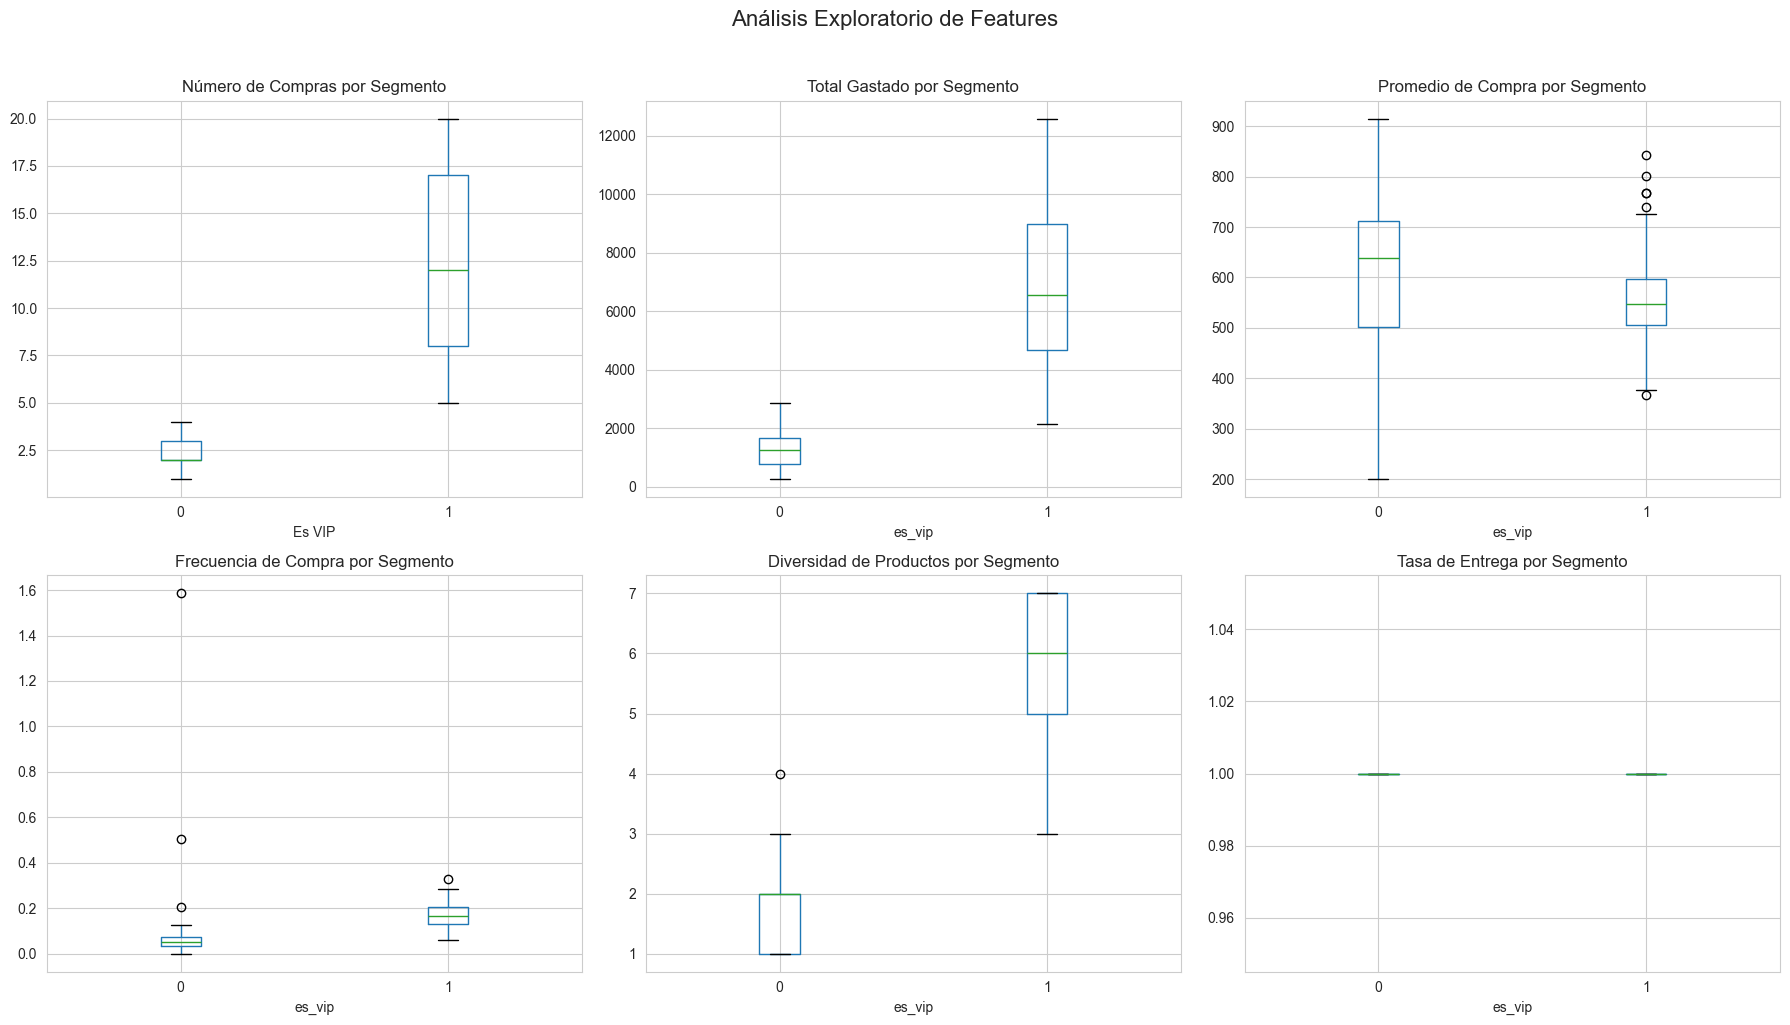

In [15]:
# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Distribución de número de compras por segmento
df_ml.boxplot(column='num_compras', by='es_vip', ax=axes[0, 0])
axes[0, 0].set_title('Número de Compras por Segmento')
axes[0, 0].set_xlabel('Es VIP')

# 2. Distribución de total gastado
df_ml.boxplot(column='total_gastado', by='es_vip', ax=axes[0, 1])
axes[0, 1].set_title('Total Gastado por Segmento')

# 3. Promedio de compra
df_ml.boxplot(column='promedio_compra', by='es_vip', ax=axes[0, 2])
axes[0, 2].set_title('Promedio de Compra por Segmento')

# 4. Frecuencia de compra
df_ml.boxplot(column='frecuencia_compra', by='es_vip', ax=axes[1, 0])
axes[1, 0].set_title('Frecuencia de Compra por Segmento')

# 5. Productos diferentes
df_ml.boxplot(column='num_productos_diferentes', by='es_vip', ax=axes[1, 1])
axes[1, 1].set_title('Diversidad de Productos por Segmento')

# 6. Tasa de entrega
df_ml.boxplot(column='tasa_entrega', by='es_vip', ax=axes[1, 2])
axes[1, 2].set_title('Tasa de Entrega por Segmento')

plt.suptitle('Análisis Exploratorio de Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Entrenamiento del modelo de clasificación

Usaremos Regresión Logística para predecir si un cliente será VIP.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Preparar features
# Excluir columnas no numéricas y la variable objetivo
features_numericas = df_ml.select_dtypes(include=[np.number]).columns.tolist()
features_numericas.remove('es_vip')
if '_id' in features_numericas:
    features_numericas.remove('_id')

X = df_ml[features_numericas].fillna(0)
y = df_ml['es_vip']

print(f"Features utilizadas ({len(features_numericas)}): {features_numericas}")
print(f"\nDistribución de clases:")
print(y.value_counts())
print(f"Porcentaje VIP: {(y.sum() / len(y)) * 100:.2f}%")

Features utilizadas (22): ['puntos_fidelidad', 'num_categorias_favoritas', 'num_metodos_pago', 'num_compras', 'total_gastado', 'promedio_compra', 'compra_maxima', 'compra_minima', 'std_compra', 'total_unidades', 'promedio_unidades_por_compra', 'usa_tarjeta_credito', 'usa_paypal', 'usa_envio_express', 'promedio_costo_envio', 'pedidos_entregados', 'pedidos_cancelados', 'num_productos_diferentes', 'dias_cliente', 'frecuencia_compra', 'tasa_entrega', 'tasa_cancelacion']

Distribución de clases:
es_vip
1    159
0     41
Name: count, dtype: int64
Porcentaje VIP: 79.50%


In [17]:
# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Tamaño conjunto entrenamiento: {len(X_train)}")
print(f"Tamaño conjunto prueba: {len(X_test)}")

# Escalar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar modelo
print("\nEntrenando modelo de Regresión Logística...")
modelo = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
modelo.fit(X_train_scaled, y_train)
print("Modelo entrenado exitosamente.")

Tamaño conjunto entrenamiento: 140
Tamaño conjunto prueba: 60

Entrenando modelo de Regresión Logística...
Modelo entrenado exitosamente.


### 4.4 Evaluación del modelo

In [18]:
# Predicciones
y_pred = modelo.predict(X_test_scaled)
y_pred_proba = modelo.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("=== MÉTRICAS DE RENDIMIENTO DEL MODELO ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print("\n=== REPORTE DE CLASIFICACIÓN ===\n")
print(classification_report(y_test, y_pred, target_names=['No VIP', 'VIP']))

print("\n=== MATRIZ DE CONFUSIÓN ===\n")
print(confusion_matrix(y_test, y_pred))

=== MÉTRICAS DE RENDIMIENTO DEL MODELO ===

Accuracy: 0.9833
Precision: 1.0000
Recall: 0.9792
F1-Score: 0.9895
ROC-AUC: 0.9931

=== REPORTE DE CLASIFICACIÓN ===

              precision    recall  f1-score   support

      No VIP       0.92      1.00      0.96        12
         VIP       1.00      0.98      0.99        48

    accuracy                           0.98        60
   macro avg       0.96      0.99      0.97        60
weighted avg       0.98      0.98      0.98        60


=== MATRIZ DE CONFUSIÓN ===

[[12  0]
 [ 1 47]]


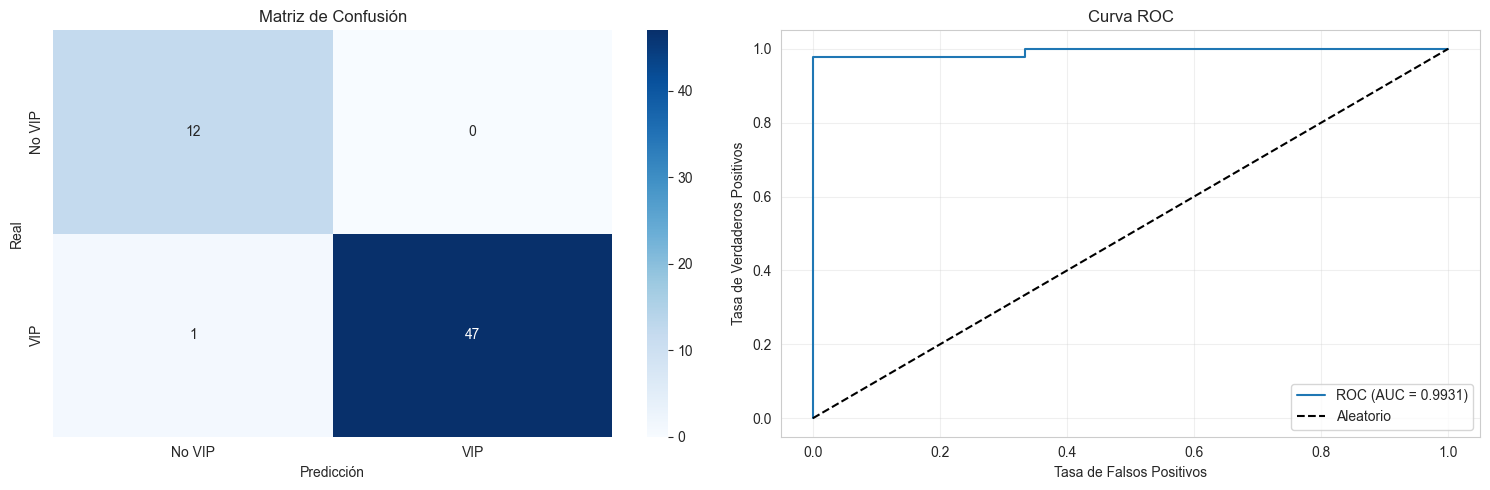

In [19]:
# Visualizar matriz de confusión y curva ROC
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_xticklabels(['No VIP', 'VIP'])
axes[0].set_yticklabels(['No VIP', 'VIP'])

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].set_title('Curva ROC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Importancia de features

=== IMPORTANCIA DE FEATURES (Top 10) ===

                     feature  coeficiente  abs_coeficiente
17  num_productos_diferentes     1.603846         1.603846
4              total_gastado     0.962534         0.962534
11       usa_tarjeta_credito     0.933458         0.933458
15        pedidos_entregados     0.933458         0.933458
3                num_compras     0.933458         0.933458
9             total_unidades     0.860208         0.860208
7              compra_minima    -0.596761         0.596761
14      promedio_costo_envio    -0.521089         0.521089
6              compra_maxima     0.385382         0.385382
8                 std_compra    -0.221233         0.221233


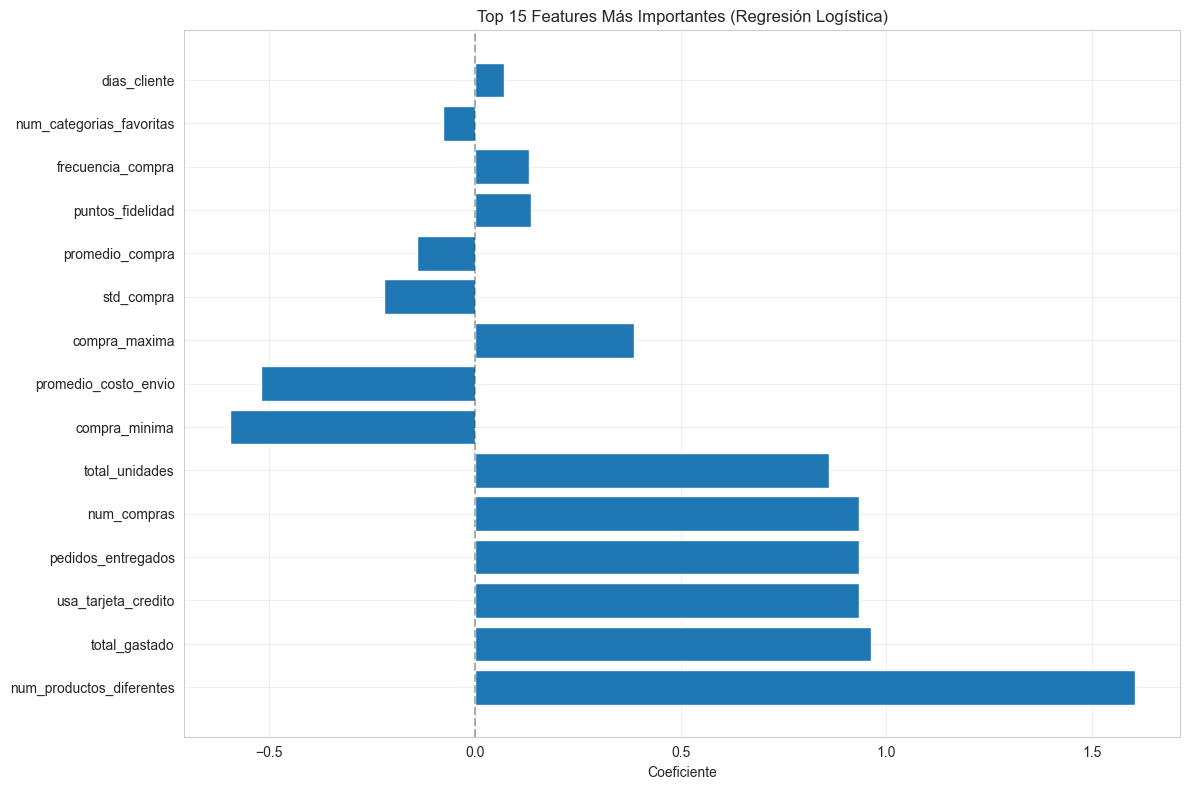

In [20]:
# Obtener coeficientes del modelo
importancias = pd.DataFrame({
    'feature': features_numericas,
    'coeficiente': modelo.coef_[0],
    'abs_coeficiente': np.abs(modelo.coef_[0])
}).sort_values('abs_coeficiente', ascending=False)

print("=== IMPORTANCIA DE FEATURES (Top 10) ===\n")
print(importancias.head(10))

# Visualizar
plt.figure(figsize=(12, 8))
top_features = importancias.head(15)
plt.barh(range(len(top_features)), top_features['coeficiente'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Coeficiente')
plt.title('Top 15 Features Más Importantes (Regresión Logística)')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.6 Predicciones en nuevos clientes

Demostramos cómo usar el modelo para predecir nuevos clientes.

In [21]:
# Seleccionar algunos clientes del conjunto de prueba
indices_ejemplo = [0, 5, 10, 15, 20]
ejemplos = X_test.iloc[indices_ejemplo]
ejemplos_scaled = scaler.transform(ejemplos)

# Hacer predicciones
predicciones = modelo.predict(ejemplos_scaled)
probabilidades = modelo.predict_proba(ejemplos_scaled)[:, 1]

print("=== PREDICCIONES EN CLIENTES DE EJEMPLO ===\n")
for i, (idx, pred, prob) in enumerate(zip(indices_ejemplo, predicciones, probabilidades)):
    real = y_test.iloc[idx]
    print(f"Cliente {i+1}:")
    print(f"  Número de compras: {ejemplos.iloc[i]['num_compras']:.0f}")
    print(f"  Total gastado: ${ejemplos.iloc[i]['total_gastado']:.2f}")
    print(f"  Predicción: {'VIP' if pred == 1 else 'No VIP'} (probabilidad: {prob:.2%})")
    print(f"  Real: {'VIP' if real == 1 else 'No VIP'}")
    print(f"  ✓ Correcto" if pred == real else "  ✗ Incorrecto")
    print()

=== PREDICCIONES EN CLIENTES DE EJEMPLO ===

Cliente 1:
  Número de compras: 18
  Total gastado: $11212.94
  Predicción: VIP (probabilidad: 100.00%)
  Real: VIP
  ✓ Correcto

Cliente 2:
  Número de compras: 7
  Total gastado: $4561.57
  Predicción: VIP (probabilidad: 94.15%)
  Real: VIP
  ✓ Correcto

Cliente 3:
  Número de compras: 11
  Total gastado: $6490.76
  Predicción: VIP (probabilidad: 99.82%)
  Real: VIP
  ✓ Correcto

Cliente 4:
  Número de compras: 10
  Total gastado: $4818.45
  Predicción: VIP (probabilidad: 99.63%)
  Real: VIP
  ✓ Correcto

Cliente 5:
  Número de compras: 17
  Total gastado: $8968.59
  Predicción: VIP (probabilidad: 100.00%)
  Real: VIP
  ✓ Correcto



### 4.7 Guardar Predicciones en MongoDB

Guardamos las predicciones de vuelta en MongoDB para uso en producción.

In [22]:
# Hacer predicciones para todos los clientes
X_todos_scaled = scaler.transform(X)
predicciones_todos = modelo.predict(X_todos_scaled)
probabilidades_todos = modelo.predict_proba(X_todos_scaled)[:, 1]

# Crear documentos para insertar
predicciones_ml = []
for i, (idx, pred, prob) in enumerate(zip(df_ml['_id'], predicciones_todos, probabilidades_todos)):
    predicciones_ml.append({
        "_id": idx,
        "prediccion_vip": int(pred),
        "probabilidad_vip": float(prob),
        "fecha_prediccion": datetime.now(),
        "modelo_version": "1.0",
        "features_usadas": features_numericas
    })

# Guardar en colección de predicciones usando $merge
print("Guardando predicciones en MongoDB...")
db.predicciones_clientes.drop()  # Limpiar colección anterior
db.predicciones_clientes.insert_many(predicciones_ml)
print(f"Predicciones guardadas: {len(predicciones_ml)}")

# Verificar
muestra = list(db.predicciones_clientes.find().limit(3))
print("\n=== MUESTRA DE PREDICCIONES GUARDADAS ===\n")
print(json.dumps(muestra, indent=2, default=str))

Guardando predicciones en MongoDB...
Predicciones guardadas: 200

=== MUESTRA DE PREDICCIONES GUARDADAS ===

[
  {
    "_id": "CL171",
    "prediccion_vip": 1,
    "probabilidad_vip": 0.999979269940382,
    "fecha_prediccion": "2026-05-04 02:26:59.525000",
    "modelo_version": "1.0",
    "features_usadas": [
      "puntos_fidelidad",
      "num_categorias_favoritas",
      "num_metodos_pago",
      "num_compras",
      "total_gastado",
      "promedio_compra",
      "compra_maxima",
      "compra_minima",
      "std_compra",
      "total_unidades",
      "promedio_unidades_por_compra",
      "usa_tarjeta_credito",
      "usa_paypal",
      "usa_envio_express",
      "promedio_costo_envio",
      "pedidos_entregados",
      "pedidos_cancelados",
      "num_productos_diferentes",
      "dias_cliente",
      "frecuencia_compra",
      "tasa_entrega",
      "tasa_cancelacion"
    ]
  },
  {
    "_id": "CL76",
    "prediccion_vip": 1,
    "probabilidad_vip": 0.9999969593216533,
    "fecha_

## 5. Ejercicios Prácticos

Ahora es tu turno de aplicar lo aprendido.

### Ejercicio 1: Vista materializada de análisis de productos

Crea una vista materializada que contenga análisis completo de productos:
- Total de unidades vendidas
- Ingresos totales por producto
- Lista de clientes que lo han comprado (usando $push)
- Precio promedio, máximo y mínimo
- Tendencia de ventas por mes
- Ciudades donde más se vende

Usa $merge para actualizar la vista y luego consulta los top 10 productos más vendidos.

In [ ]:
# Tu código aquí
pipeline_productos_mv = [
    # Completa el pipeline
]

# comprasColl.aggregate(pipeline_productos_mv)

### Ejercicio 2: Modelo de predicción de método de pago

Crea un modelo de Machine Learning que prediga qué método de pago preferirá un cliente en su próxima compra:

1. Extrae features usando agregación (historial de métodos de pago, monto promedio, tipo de productos, etc.)
2. Entrena un modelo de clasificación multiclase
3. Evalúa el modelo con métricas apropiadas
4. Guarda las predicciones en una nueva colección usando $merge

**Bonus:** Usa el análisis de importancia de features para identificar qué características son más predictivas del método de pago.

In [ ]:
# Tu código aquí
pipeline_metodo_pago_ml = [
    # Completa el pipeline para extraer features
]

# Extrae datos, entrena modelo y evalúa

## 6. Conclusiones y mejores prácticas

En este taller avanzado hemos explorado:

### Agregaciones avanzadas:
- Construcción de documentos JSON complejos con múltiples niveles de anidación
- Uso de operadores de acumulación ($push, $addToSet) para crear arrays dinámicos
- Cálculo de múltiples métricas (sum, avg, max, min, stdDev) en una sola agregación
- Documentos embebidos con información calculada en tiempo real

### Vistas materializadas:
- Creación de vistas pre-calculadas con $merge
- Actualización incremental para optimizar rendimiento
- Consultas ultra-rápidas desde vistas materializadas
- Mantenimiento de múltiples vistas para diferentes casos de uso

### Machine Learning:
- Preparación de datos directamente desde MongoDB
- Feature engineering usando agregación
- Entrenamiento y evaluación de modelos
- Integración de predicciones con la base de datos

### Mejores prácticas:
1. **Optimización**: Usa índices apropiados antes de ejecutar agregaciones complejas
2. **Incremental**: Actualiza vistas materializadas solo cuando sea necesario
3. **Monitoreo**: Registra tiempos de ejecución y optimiza pipelines lentos
4. **Validación**: Siempre valida los resultados de agregaciones complejas
5. **Documentación**: Documenta pipelines complejos para mantenimiento futuro

### Recursos adicionales:
- [MongoDB Aggregation Reference](https://docs.mongodb.com/manual/reference/operator/aggregation/)
- [MongoDB Performance Best Practices](https://www.mongodb.com/docs/manual/administration/analyzing-mongodb-performance/)
- [Scikit-learn Documentation](https://scikit-learn.org/stable/documentation.html)